In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.interpolate import griddata
from matplotlib.path import Path
import matplotlib.pyplot as plt
import src.processing as cl
import src.plotting as pl

In [2]:
# --- Load digitised data ---
folder = '/home/bmelo/Quarry/Eire-velocity_models/out_models/ICSSP/'
layers = pd.read_csv(folder + 'digitised/all-layers.csv')
layers = layers[(layers['x'] >= 50) & (layers['x'] <= 300)]
df_values = pd.read_csv(folder + 'digitised/velocity_picks_with_values.csv')
df_values['x'] = df_values['x'] * (400.0 / 350.0)   #correction for digitised data

# Set boundaries; selecting where more points are available within the profile
x_min = 50
x_max = 300
y_bottom = 40  # plotting range
y_top = 0

In [3]:
# Create close polygon interfaces for each layer
interfaces = {}
layer_names = sorted(layers['layer'].unique())
for layer in layer_names:
    group = layers[layers['layer'] == layer].sort_values('x')
    left_y = group[group['x'] == group['x'].min()]['y'].values[0]
    right_y = group[group['x'] == group['x'].max()]['y'].values[0]
    extended_x = [x_min] + group['x'].tolist() + [x_max]
    extended_y = [left_y] + group['y'].tolist() + [right_y]
    interfaces[layer] = list(zip(extended_x, extended_y))

# Add virtual top and bottom interfaces
interfaces['__top__'] = [(x_min, y_top), (x_max, y_top)]
interfaces['__bottom__'] = [(x_min, y_bottom), (x_max, y_bottom)]

# Build polygons
all_layers = ['__top__'] + layer_names + ['__bottom__']
polygons = []

for i in range(len(all_layers) - 1):
    top_name = all_layers[i]
    bot_name = all_layers[i + 1]
    top = interfaces[top_name]
    bottom = interfaces[bot_name]
    poly = top + bottom[::-1]
    polygons.append((i, poly))

#Save polygons to CSV
layer_rows = []
for layer, points in interfaces.items():
    for xi, zi in points:
        layer_rows.append({"layer": layer, 'x': xi, 'z': zi})

layer_df = pd.DataFrame(layer_rows)
layer_df.to_csv(folder + 'ICSSP_layers.csv', index=False)

Interpolating layer 0
Interpolating layer 1
Interpolating layer 2
Interpolating layer 3
Interpolating layer 4
Interpolating layer 5
Interpolating layer 6
Interpolating layer 7


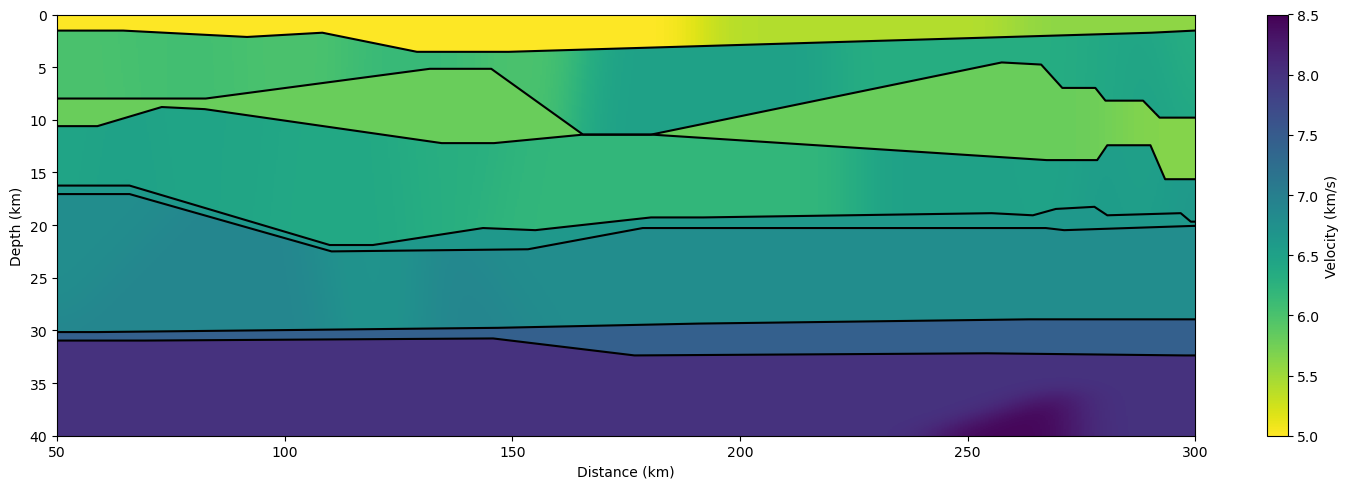

In [4]:
# Interpolate velocity for each layer separately and plot for checking
# layer_data = []
# fig, ax = plt.subplots(figsize=(15, 5))
# for name, poly in polygons:
    
#     orig_poly = poly
#     path = Path(poly)
#     # Select velocity points inside this polygon
#     in_layer = path.contains_points(df_values[['x', 'y']].values)
#     vel_in_layer = df_values[in_layer]
    
#     # If there are not enough points, treat as transition layer
#     if len(vel_in_layer) < 3:
        
#         print(f"Layer {name} is a transition")
#         idx = polygons.index((name, orig_poly))
#         if idx > 0:
#             poly_above = polygons[idx - 1][1]
#         if idx < len(polygons) - 1:
#             poly_below = polygons[idx + 1][1]
#         X_layer, Y_layer, V_masked = cl.interpolate_transition_layer(poly, poly_above, poly_below, df_values, x_bounds=(x_min, x_max), resolution=[700,200])
        
#     else:
#         print(f"Interpolate velocities in layer {name} with {len(vel_in_layer)} points")
#         X_layer, Y_layer, V_masked = cl.interpolate_within_layer(poly, df_values, resolution=[700,200])
    
#     ax.pcolormesh(X_layer, Y_layer, V_masked, shading='auto', cmap='viridis_r', vmin=5, vmax=8.5)
#     layer_data.append((X_layer, Y_layer, V_masked))
# Plot layer boundaries
layer_data = []
fig, ax = plt.subplots(figsize=(15, 5))

for i, (name, poly) in enumerate(polygons):
    print(f"Interpolating layer {name}")

    # Determine above and below polygons, if they exist
    poly_above = polygons[i - 1][1] if i > 0 else None
    poly_below = polygons[i + 1][1] if i < len(polygons) - 1 else None

    X_layer, Y_layer, V_masked = cl.interpolate_layer(
        poly,
        df_values,
        polygon_above=poly_above,
        polygon_below=poly_below,
        x_bounds=(x_min, x_max),
        resolution=[700, 200]
    )

    ax.pcolormesh(X_layer, Y_layer, V_masked, shading='auto', cmap='viridis_r', vmin=5, vmax=8.5)
    layer_data.append((X_layer, Y_layer, V_masked))


for layer, points in interfaces.items():
    if isinstance(layer, str) and layer.startswith("__"):
        continue
    xs, ys = zip(*points)
    ax.plot(xs, ys, 'k-', linewidth=1.5)
    
# Plot to check layer interpolation
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_bottom, y_top)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Depth (km)")
cb = plt.colorbar(ax.collections[0], ax=ax)
cb.set_label("Velocity (km/s)")
plt.tight_layout()
plt.show()

In [11]:
# Create full grid
xi = np.linspace(x_min, x_max, 700)   # common x
yi = np.linspace(y_top, y_bottom, 200)     # common y
X_common, Y_common = np.meshgrid(xi, yi)

# Prepare a list to hold all interpolated arrays
interpolated_layers = []
for X, Y, V in layer_data:
    points = np.vstack((X.ravel(), Y.ravel())).T
    values = V.filled(np.nan).ravel()
    V_interp = griddata(points, values, (X_common, Y_common), method='linear')
    interpolated_layers.append(V_interp)
# Combine all interpolated layers into a single velocity field
velocity_combined = np.nanmean(interpolated_layers, axis=0)
velocity_filled = cl.fill_nan_nearest(velocity_combined)

/tmp/ipykernel_3744125/880711955.py:14: RuntimeWarning: Mean of empty slice
  velocity_combined = np.nanmean(interpolated_layers, axis=0)


In [12]:
#Convert x_grid to geographic coordinates
coords = "/home/bmelo/Quarry/Eire-velocity_models/line_coords"
start_lat, start_lon, end_lat, end_lon = cl.get_profile_coords("ICSS","P",coords)
lon_grid, lat_grid = cl.interpolate_profile_coords(xi-50, start_lat, start_lon, end_lat, end_lon)
#50 km offset is applied to match the digitised data
print(min(lon_grid), max(lon_grid), min(lat_grid), max(lat_grid), min(xi), max(xi))

-9.5 -6.367631507368873 52.6 53.829765344667216 50.0 300.0


In [14]:
# --- SAVE INTERPOLATED GRID TO NETCDF ---
ds = xr.Dataset(
    data_vars={
        "vp": (("z", "x"), velocity_filled),
    },
    coords={
        "x": xi,
        "lon": ("x", lon_grid),
        "lat": ("x", lat_grid),
        "z": yi
    },
    attrs={
        "title": "Interpolated 2D Vp model",
        "description": "digitised from ICSSP profile",
        "units": "Vp in km/s, depth in km, distance in km"
    }
)
ds.to_netcdf(folder+"ICSSP_vp.nc")
print("Interpolated Vp grid saved as ICSSP_vp.nc")

Interpolated Vp grid saved as ICSSP_vp.nc


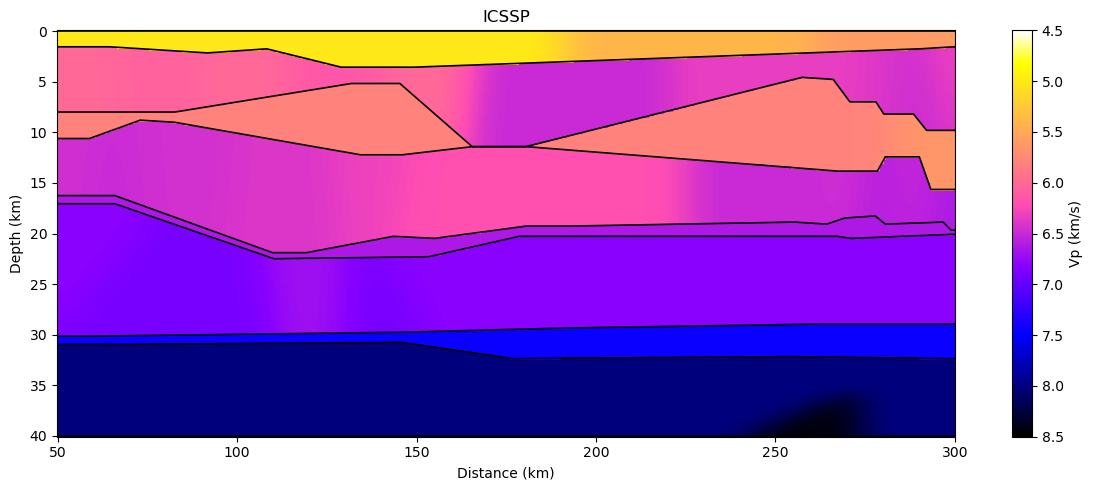

In [15]:
#check if the grid is correct
pl.plot_section(folder+"ICSSP_vp.nc", folder + "ICSSP_layers.csv", title = "ICSSP", output=folder+"ICSSP_vp.png")

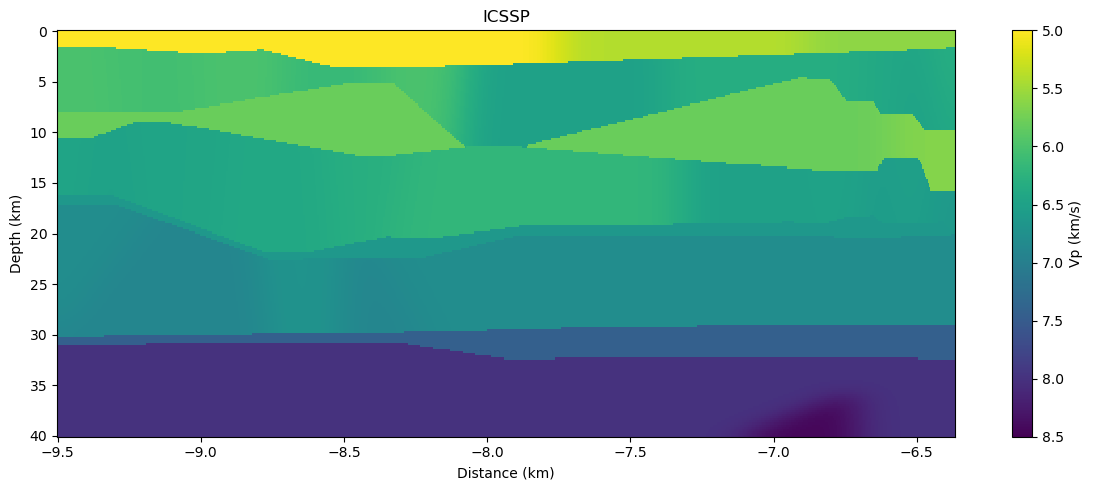

<xarray.DataArray 'lon' ()> Size: 8B
array(-9.5)
Coordinates:
    x        float64 8B 50.0
    lon      float64 8B -9.5
    lat      float64 8B ...


In [ ]:
# Load data
#testing coordinates
bounds = pd.read_csv(folder + "ICSSP_layers.csv")
ds = xr.open_dataset(folder+"ICSSP_vp.nc")
title = "ICSSP"; output=folder+"ICSSP_vp.png"

# Extract coordinates and Vp
x = ds["lon"]
z = ds["z"]
vp = ds["vp"]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
c = ax.pcolormesh(x, z, vp, shading='auto', cmap='viridis_r', vmin=5, vmax=8.5)

# for id, group in bounds.groupby("layer"):
#     ax.plot(group["x"], group["z"], color='k', linewidth=1.2)

ax.invert_yaxis()
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Depth (km)")
cbar = fig.colorbar(c, ax=ax, label="Vp (km/s)")
cbar.ax.invert_yaxis()
ax.set_title(title)
plt.tight_layout()

# Save and show
fig.savefig(output, dpi=300)
plt.show()